# Анализ и сегментация пользователей
## Цель

Исследовать покупательское поведение пользователей:

- определить долю и характеристики покупателей
- измерить частоту заказов и повторные покупки
- построить поведенческие сегменты
- провести когортный анализ активности и покупок

## Ограничения

В данных отсутствуют стоимость товаров и сумма заказа, поэтому
прибыль, средний чек и Monetary-компонент RFM рассчитать невозможно.
Сегментация основана на активности, давности и частоте заказов

In [61]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data" / "processed").exists():
    PROJECT_DIR = CURRENT_DIR
elif (CURRENT_DIR.parent / "data" / "processed").exists():
    PROJECT_DIR = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Не удалось найти папку data/processed. "
        f"Текущая папка: {CURRENT_DIR}"
    )

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

print("Папка проекта:", PROJECT_DIR)

Папка проекта: C:\Users\Тимофей\PycharmProjects\ecommerce-customer-analysis


In [62]:
events = pd.read_csv(
    PROCESSED_DIR / "clean_events.csv",
    usecols=[
        "visitorid",
        "event",
        "itemid",
        "transactionid",
        "datetime"
    ],
    dtype={
        "visitorid": "int64",
        "event": "category",
        "itemid": "int64",
        "transactionid": "Int64"
    }
)

events["datetime"] = pd.to_datetime(
    events["datetime"],
    format="ISO8601",
    utc=True
).dt.as_unit("ns")

assert events["visitorid"].notna().all()
assert events["itemid"].notna().all()
assert events["datetime"].notna().all()

print("Событий:", len(events))
print("Пользователей:", events["visitorid"].nunique())

Событий: 2755641
Пользователей: 1407580


_Бизнес-вопрос_: cколько реальных заказов содержится в данных и можно ли однозначно связать каждый заказ с пользователем?

In [63]:
transaction_events = events[
    events["event"] == "transaction"
].copy()

assert transaction_events["transactionid"].notna().all()

print(
    "Событий покупки:",
    len(transaction_events)
)

print(
    "Уникальных transactionid:",
    transaction_events["transactionid"].nunique()
)

Событий покупки: 22457
Уникальных transactionid: 17672


In [64]:
visitors_per_order = (
    transaction_events
    .groupby("transactionid")["visitorid"]
    .nunique()
)

print(
    "Максимум пользователей на один заказ:",
    visitors_per_order.max()
)

print(
    "Заказов с несколькими пользователями:",
    (visitors_per_order > 1).sum()
)

assert visitors_per_order.max() == 1

Максимум пользователей на один заказ: 1
Заказов с несколькими пользователями: 0


In [65]:
orders = (
    transaction_events
    .groupby("transactionid")
    .agg(
        visitorid=("visitorid", "first"),
        order_time=("datetime", "min"),
        order_last_event=("datetime", "max"),
        unique_items=("itemid", "nunique"),
        transaction_rows=("itemid", "size")
    )
    .reset_index()
)

orders["order_duration_minutes"] = (
    orders["order_last_event"]
    - orders["order_time"]
).dt.total_seconds() / 60

assert len(orders) == transaction_events["transactionid"].nunique()
assert orders["visitorid"].notna().all()

display(orders.head())
display(orders.describe())

,transactionid,visitorid,order_time,order_last_event,unique_items,transaction_rows,order_duration_minutes
0,0,90352,2015-06-15 21:36:37.081000+00:00,2015-06-15 21:36:37.081000+00:00,1,1,0.0
1,1,1150086,2015-07-14 18:30:08.851000+00:00,2015-07-14 18:30:08.851000+00:00,1,1,0.0
2,2,556967,2015-06-03 18:02:29.857000+00:00,2015-06-03 18:02:29.857000+00:00,1,1,0.0
3,3,424452,2015-06-22 00:12:41.626000+00:00,2015-06-22 00:12:41.626000+00:00,1,1,0.0
4,4,531661,2015-06-07 22:40:24.966000+00:00,2015-06-07 22:40:24.966000+00:00,1,1,0.0


,transactionid,visitorid,unique_items,transaction_rows,order_duration_minutes
count,17672.0,1.767200e+04,17672.000000,17672.000000,17672.000000
mean,8835.5,7.016880e+05,1.263185,1.270767,0.076122
std,5101.611314,4.035521e+05,0.940747,0.974793,3.843866
min,0.0,1.720000e+02,1.000000,1.000000,0.000000
25%,4417.75,3.483632e+05,1.000000,1.000000,0.000000
50%,8835.5,7.110025e+05,1.000000,1.000000,0.000000
75%,13253.25,1.064374e+06,1.000000,1.000000,0.000000
max,17671.0,1.407398e+06,31.000000,31.000000,322.032817


In [66]:
order_items = (
    transaction_events[
        [
            "transactionid",
            "visitorid",
            "itemid"
        ]
    ]
    .drop_duplicates(
        ["transactionid", "itemid"]
    )
)

assert (
    order_items
    .groupby("transactionid")["visitorid"]
    .nunique()
    .max()
    == 1
)

print("Заказов:", len(orders))
print(
    "Уникальных пар «заказ–товар»:",
    len(order_items)
)

Заказов: 17672
Уникальных пар «заказ–товар»: 22323


In [67]:
events["event_date"] = (
    events["datetime"].dt.floor("D")
)

user_activity = (
    events
    .groupby("visitorid")
    .agg(
        first_event=("datetime", "min"),
        last_event=("datetime", "max"),
        total_events=("event", "size"),
        active_days=("event_date", "nunique"),
        unique_interacted_items=("itemid", "nunique")
    )
)

user_event_counts = (
    events
    .groupby(
        ["visitorid", "event"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=["view", "addtocart", "transaction"],
        fill_value=0
    )
    .rename(columns={
        "view": "view_events",
        "addtocart": "cart_events",
        "transaction": "transaction_events"
    })
)

In [68]:
user_order_metrics = (
    orders
    .groupby("visitorid")
    .agg(
        orders_count=("transactionid", "nunique"),
        first_order=("order_time", "min"),
        last_order=("order_time", "max"),
        average_unique_items_per_order=(
            "unique_items",
            "mean"
        ),
        maximum_unique_items_per_order=(
            "unique_items",
            "max"
        )
    )
)

user_purchased_items = (
    order_items
    .groupby("visitorid")
    .agg(
        purchased_item_pairs=("itemid", "size"),
        unique_purchased_items=("itemid", "nunique")
    )
)

In [69]:
user_metrics = (
    user_activity
    .join(user_event_counts)
    .join(user_order_metrics)
    .join(user_purchased_items)
)

zero_fill_columns = [
    "orders_count",
    "average_unique_items_per_order",
    "maximum_unique_items_per_order",
    "purchased_item_pairs",
    "unique_purchased_items"
]

user_metrics[zero_fill_columns] = (
    user_metrics[zero_fill_columns]
    .fillna(0)
)

integer_columns = [
    "orders_count",
    "maximum_unique_items_per_order",
    "purchased_item_pairs",
    "unique_purchased_items"
]

user_metrics[integer_columns] = (
    user_metrics[integer_columns].astype("int64")
)

user_metrics["has_purchase"] = (
    user_metrics["orders_count"] > 0
)

In [70]:
analysis_date = events["datetime"].max().normalize()

user_metrics["activity_recency_days"] = (
    analysis_date
    - user_metrics["last_event"].dt.normalize()
).dt.days

user_metrics["purchase_recency_days"] = (
    analysis_date
    - user_metrics["last_order"].dt.normalize()
).dt.days

user_metrics["observed_lifetime_days"] = (
    user_metrics["last_event"].dt.normalize()
    - user_metrics["first_event"].dt.normalize()
).dt.days

In [71]:
assert len(user_metrics) == events["visitorid"].nunique()
assert user_metrics["orders_count"].sum() == len(orders)

assert (
    user_metrics["purchased_item_pairs"].sum()
    == len(order_items)
)

assert (
    user_metrics["has_purchase"].sum()
    == orders["visitorid"].nunique()
)

print("Пользователей:", len(user_metrics))
print(
    "Покупателей:",
    user_metrics["has_purchase"].sum()
)
print(
    "Заказов:",
    user_metrics["orders_count"].sum()
)

display(user_metrics.head())

Пользователей: 1407580
Покупателей: 11719
Заказов: 17672


,first_event,last_event,total_events,active_days,unique_interacted_items,view_events,cart_events,transaction_events,orders_count,first_order,last_order,average_unique_items_per_order,maximum_unique_items_per_order,purchased_item_pairs,unique_purchased_items,has_purchase,activity_recency_days,purchase_recency_days,observed_lifetime_days
visitorid,,,,,,,,,,,,,,,,,,,
0,2015-09-11 20:49:49.439000+00:00,2015-09-11 20:55:17.175000+00:00,3,1,3,3,0,0,0,NaT,NaT,0.0,0,0,0,False,7,NaN,0
1,2015-08-13 17:46:06.444000+00:00,2015-08-13 17:46:06.444000+00:00,1,1,1,1,0,0,0,NaT,NaT,0.0,0,0,0,False,36,NaN,0
2,2015-08-07 17:51:44.567000+00:00,2015-08-07 18:20:57.845000+00:00,8,1,4,8,0,0,0,NaT,NaT,0.0,0,0,0,False,42,NaN,0
3,2015-08-01 07:10:35.296000+00:00,2015-08-01 07:10:35.296000+00:00,1,1,1,1,0,0,0,NaT,NaT,0.0,0,0,0,False,48,NaN,0
4,2015-09-15 21:24:27.167000+00:00,2015-09-15 21:24:27.167000+00:00,1,1,1,1,0,0,0,NaT,NaT,0.0,0,0,0,False,3,NaN,0


_Бизнес-вопрос_: какая доля покупателей сделала повторный заказ и насколько часто пользователи возвращаются за покупками?

In [72]:
buyers = user_metrics[
    user_metrics["has_purchase"]
].copy()

buyers["is_repeat_buyer"] = (
    buyers["orders_count"] >= 2
)

buyer_summary = pd.Series({
    "Покупателей": len(buyers),

    "Покупателей с одним заказом": (
        buyers["orders_count"] == 1
    ).sum(),

    "Повторных покупателей": (
        buyers["is_repeat_buyer"]
    ).sum(),

    "Доля повторных покупателей, %": (
        buyers["is_repeat_buyer"].mean()
        * 100
    ),

    "Среднее заказов на покупателя": (
        buyers["orders_count"].mean()
    ),

    "Медиана заказов на покупателя": (
        buyers["orders_count"].median()
    )
})

display(buyer_summary.round(2))

Покупателей                      11719.00
Покупателей с одним заказом      10656.00
Повторных покупателей             1063.00
Доля повторных покупателей, %        9.07
Среднее заказов на покупателя        1.51
Медиана заказов на покупателя        1.00
dtype: float64

In [73]:
display(
    buyers["orders_count"]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

count    11719.000000
mean         1.507978
std          7.344491
min          1.000000
50%          1.000000
75%          1.000000
90%          1.000000
95%          2.000000
99%          6.000000
max        502.000000
Name: orders_count, dtype: float64

In [74]:
order_frequency = (
    buyers["orders_count"]
    .value_counts()
    .sort_index()
    .rename("buyers_count")
    .to_frame()
)

order_frequency["buyers_share"] = (
    order_frequency["buyers_count"]
    / len(buyers)
    * 100
)

display(order_frequency.head(15).round(2))

,buyers_count,buyers_share
orders_count,,
1,10656,90.93
2,748,6.38
3,133,1.13
4,44,0.38
5,13,0.11
6,13,0.11
7,9,0.08
8,6,0.05
9,7,0.06


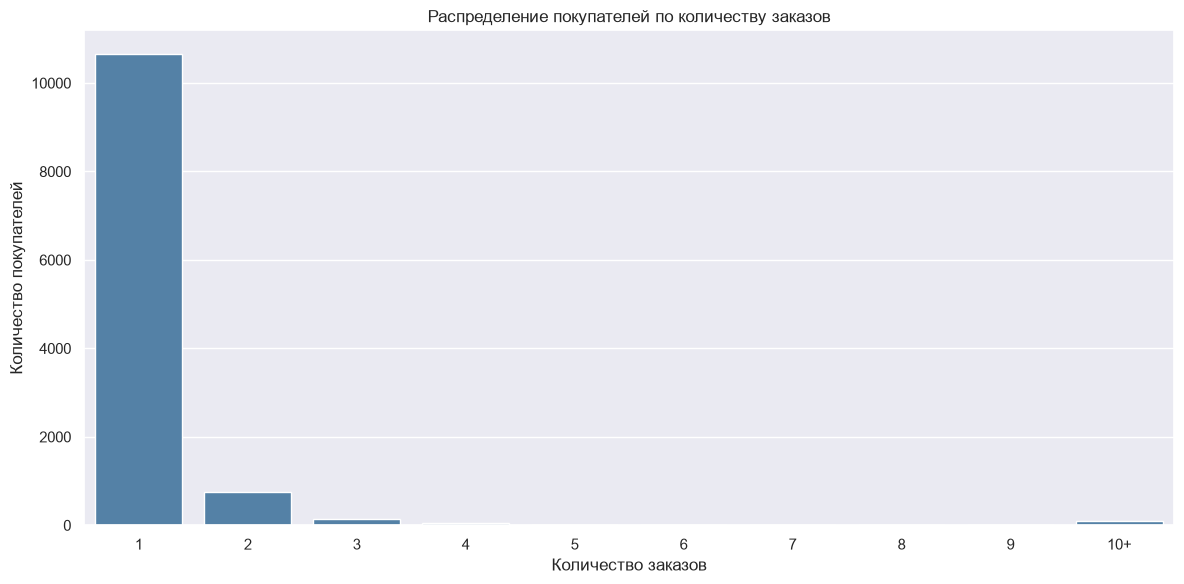

In [75]:
buyers["orders_group"] = np.where(
    buyers["orders_count"] >= 10,
    "10+",
    buyers["orders_count"].astype(str)
)

orders_group_order = [
    "1", "2", "3", "4", "5",
    "6", "7", "8", "9", "10+"
]

orders_group_counts = (
    buyers["orders_group"]
    .value_counts()
    .reindex(
        orders_group_order,
        fill_value=0
    )
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=orders_group_counts.index,
    y=orders_group_counts.values,
    color="steelblue"
)

plt.title("Распределение покупателей по количеству заказов")
plt.xlabel("Количество заказов")
plt.ylabel("Количество покупателей")
plt.tight_layout()
plt.show()

**Частота заказов**

Из 11 719 покупателей 10 656, или 90,93%, совершили только один
заказ. Повторный заказ наблюдается у 1063 покупателей — 9,07%

Медианное число заказов равно одному, тогда как среднее составляет
1,51. Разница объясняется небольшим количеством крайне активных
пользователей. У 99% покупателей не более шести заказов, но
максимальное значение достигает 502

Таких пользователей нельзя удалять автоматически: высокое значение
может отражать как реального постоянного клиента, так и техническую
или коммерческую учетную запись

_Бизнес-вопрос_: какая доля заказов создается наиболее активными покупателями?

In [76]:
buyers["purchase_span_days"] = (
    buyers["last_order"].dt.normalize()
    - buyers["first_order"].dt.normalize()
).dt.days

buyers["orders_per_active_day"] = (
    buyers["orders_count"]
    / buyers["active_days"]
)

top_buyers = (
    buyers
    .sort_values(
        "orders_count",
        ascending=False
    )
    [
        [
            "orders_count",
            "first_order",
            "last_order",
            "purchase_span_days",
            "active_days",
            "orders_per_active_day",
            "unique_purchased_items",
            "purchased_item_pairs",
            "average_unique_items_per_order",
            "total_events"
        ]
    ]
    .head(10)
)

display(
    top_buyers.round({
        "orders_per_active_day": 2,
        "average_unique_items_per_order": 2
    })
)

,orders_count,first_order,last_order,purchase_span_days,active_days,orders_per_active_day,unique_purchased_items,purchased_item_pairs,average_unique_items_per_order,total_events
visitorid,,,,,,,,,,
1150086,502,2015-06-11 15:28:45.614000+00:00,2015-09-17 00:24:58.943000+00:00,98,74,6.78,532,559,1.11,7757
152963,278,2015-08-03 17:16:29.561000+00:00,2015-09-18 02:43:12.017000+00:00,46,38,7.32,319,349,1.26,3024
530559,221,2015-06-15 19:36:51.103000+00:00,2015-09-12 23:16:45.863000+00:00,89,73,3.03,259,284,1.29,4328
684514,162,2015-06-17 16:47:14.489000+00:00,2015-07-06 20:00:53.922000+00:00,19,18,9.00,184,189,1.17,2246
76757,155,2015-05-06 17:53:17.506000+00:00,2015-06-24 00:34:21.485000+00:00,49,28,5.54,177,185,1.19,1883
861299,148,2015-07-24 16:40:58.756000+00:00,2015-08-19 02:23:13.196000+00:00,26,21,7.05,183,188,1.27,1991
138131,137,2015-05-04 15:59:58.661000+00:00,2015-07-02 15:55:18.473000+00:00,59,45,3.04,161,173,1.26,1611
247235,124,2015-08-13 22:28:15.027000+00:00,2015-09-14 22:58:30.256000+00:00,32,19,6.53,129,132,1.06,1698
1297062,111,2015-07-03 18:06:20.969000+00:00,2015-08-03 23:27:48.159000+00:00,31,24,4.62,129,136,1.23,1822


In [77]:
buyers_sorted = buyers.sort_values(
    "orders_count",
    ascending=False
)

total_orders = buyers_sorted["orders_count"].sum()

concentration_rows = []

for top_share in [0.01, 0.05, 0.10]:
    buyers_count = int(
        np.ceil(len(buyers_sorted) * top_share)
    )

    group_orders = (
        buyers_sorted
        .head(buyers_count)["orders_count"]
        .sum()
    )

    concentration_rows.append({
        "top_buyers": f"{top_share:.0%}",
        "buyers_count": buyers_count,
        "orders_count": group_orders,
        "orders_share": (
            group_orders / total_orders * 100
        )
    })

order_concentration = (
    pd.DataFrame(concentration_rows)
    .set_index("top_buyers")
)

display(order_concentration.round(2))

,buyers_count,orders_count,orders_share
top_buyers,,,
1%,118,4838,27.38
5%,586,6062,34.30
10%,1172,7125,40.32


In [78]:
top_buyer_id = buyers_sorted.index[0]
top_buyer_orders = buyers_sorted.iloc[0]["orders_count"]

print("Самый активный visitorid:", top_buyer_id)
print("Заказов:", int(top_buyer_orders))
print(
    "Доля всех заказов:",
    f"{top_buyer_orders / total_orders:.2%}"
)

Самый активный visitorid: 1150086
Заказов: 502
Доля всех заказов: 2.84%


## RF-сегментация покупателей

### 1. Независимые группы Frequency и Recency

- **Frequency** — количество совершенных заказов
- **Recency** — количество дней с момента последнего заказа до окончания анализируемого периода

Поскольку более 90% покупателей совершили только один заказ, квантильное деление по частоте будет плохо отражать структуру данных. Поэтому используются интерпретируемые интервалы количества заказов

In [79]:
buyers = user_metrics.loc[user_metrics["has_purchase"]].copy()

buyers["frequency_group"] = pd.cut(
    buyers["orders_count"],
    bins=[0, 1, 3, 6, float("inf")],
    labels=[
        "1 заказ",
        "2–3 заказа",
        "4–6 заказов",
        "7+ заказов"
    ]
)

buyers["recency_group"] = pd.cut(
    buyers["purchase_recency_days"],
    bins=[-1, 7, 30, 60, float("inf")],
    labels=[
        "До 7 дней",
        "8–30 дней",
        "31–60 дней",
        "Более 60 дней"
    ]
)

In [80]:
rf_matrix = pd.crosstab(
    index=buyers["frequency_group"],
    columns=buyers["recency_group"],
    dropna=False
)

rf_matrix.index.name = "Частота покупок"
rf_matrix.columns.name = "Давность последней покупки"

display(rf_matrix)

Давность последней покупки,До 7 дней,8–30 дней,31–60 дней,Более 60 дней
Частота покупок,,,,
1 заказ,427,1710,2361,6158
2–3 заказа,42,141,206,492
4–6 заказов,5,16,14,35
7+ заказов,17,18,20,57


In [81]:
rf_matrix_share = (
    rf_matrix
    .div(rf_matrix.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

display(rf_matrix_share)

Давность последней покупки,До 7 дней,8–30 дней,31–60 дней,Более 60 дней
Частота покупок,,,,
1 заказ,4.01,16.05,22.16,57.79
2–3 заказа,4.77,16.00,23.38,55.85
4–6 заказов,7.14,22.86,20.00,50.00
7+ заказов,15.18,16.07,17.86,50.89


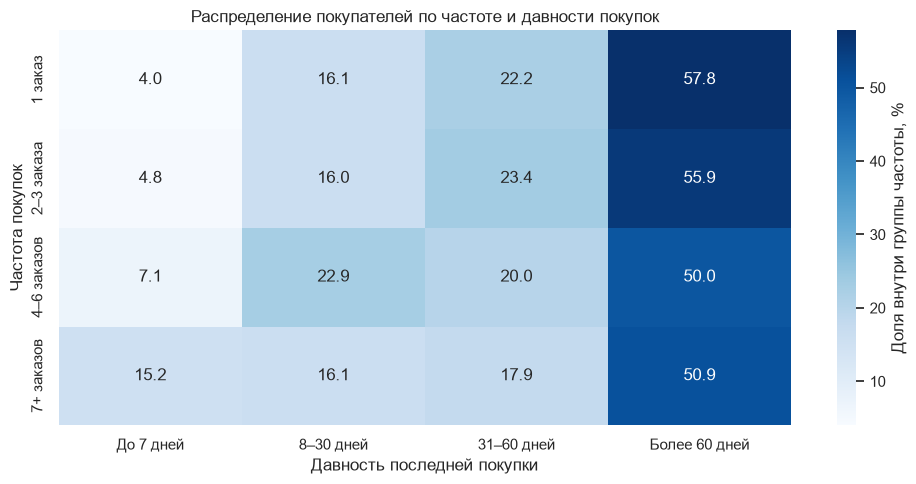

In [82]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    rf_matrix_share,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Доля внутри группы частоты, %"}
)

plt.title("Распределение покупателей по частоте и давности покупок")
plt.xlabel("Давность последней покупки")
plt.ylabel("Частота покупок")
plt.tight_layout()
plt.show()

In [83]:
conditions = [
    (buyers["orders_count"] >= 7) &
    (buyers["purchase_recency_days"] <= 30),

    (buyers["orders_count"] >= 7) &
    (buyers["purchase_recency_days"] > 30),

    (buyers["orders_count"].between(4, 6)) &
    (buyers["purchase_recency_days"] <= 30),

    (buyers["orders_count"].between(4, 6)) &
    (buyers["purchase_recency_days"] > 30),

    (buyers["orders_count"].between(2, 3)) &
    (buyers["purchase_recency_days"] <= 30),

    (buyers["orders_count"].between(2, 3)) &
    (buyers["purchase_recency_days"] > 30),

    (buyers["orders_count"] == 1) &
    (buyers["purchase_recency_days"] <= 30),

    (buyers["orders_count"] == 1) &
    (buyers["purchase_recency_days"] > 30)
]

segment_names = [
    "Сверхактивные",
    "Сверхактивные под риском",
    "Лояльные",
    "Лояльные под риском",
    "Активные повторные",
    "Повторные под риском",
    "Недавние разовые",
    "Неактивные разовые"
]

buyers["customer_segment"] = np.select(
    conditions,
    segment_names,
    default="Не определен"
)

buyers["customer_segment"].value_counts()

customer_segment
Неактивные разовые          8519
Недавние разовые            2137
Повторные под риском         698
Активные повторные           183
Сверхактивные под риском      77
Лояльные под риском           49
Сверхактивные                 35
Лояльные                      21
Name: count, dtype: int64

In [84]:
print("Всего покупателей:", len(buyers))
print("Распределено по сегментам:", buyers["customer_segment"].notna().sum())
print(
    "Неопределенных:",
    buyers["customer_segment"].eq("Не определен").sum()
)

Всего покупателей: 11719
Распределено по сегментам: 11719
Неопределенных: 0


In [85]:
segment_summary = (
    buyers
    .groupby("customer_segment")
    .agg(
        buyers_count=("orders_count", "size"),
        orders_count=("orders_count", "sum"),
        average_orders=("orders_count", "mean"),
        median_orders=("orders_count", "median"),
        median_recency_days=("purchase_recency_days", "median"),
        average_unique_items=("unique_purchased_items", "mean")
    )
)

segment_summary["buyers_share"] = (
    segment_summary["buyers_count"]
    .div(segment_summary["buyers_count"].sum())
    .mul(100)
)

segment_summary["orders_share"] = (
    segment_summary["orders_count"]
    .div(segment_summary["orders_count"].sum())
    .mul(100)
)

segment_summary = (
    segment_summary[
        [
            "buyers_count",
            "buyers_share",
            "orders_count",
            "orders_share",
            "average_orders",
            "median_orders",
            "median_recency_days",
            "average_unique_items"
        ]
    ]
    .sort_values("orders_share", ascending=False)
    .round(2)
)

display(segment_summary)

,buyers_count,buyers_share,orders_count,orders_share,average_orders,median_orders,median_recency_days,average_unique_items
customer_segment,,,,,,,,
Неактивные разовые,8519,72.69,8519,48.21,1.00,1.0,85.0,1.23
Сверхактивные под риском,77,0.66,2786,15.77,36.18,22.0,85.0,43.30
Недавние разовые,2137,18.24,2137,12.09,1.00,1.0,16.0,1.25
Сверхактивные,35,0.30,2016,11.41,57.60,17.0,8.0,66.09
Повторные под риском,698,5.96,1496,8.47,2.14,2.0,84.0,2.25
Активные повторные,183,1.56,399,2.26,2.18,2.0,15.0,2.61
Лояльные под риском,49,0.42,220,1.24,4.49,4.0,94.0,5.65
Лояльные,21,0.18,99,0.56,4.71,4.0,16.0,5.52


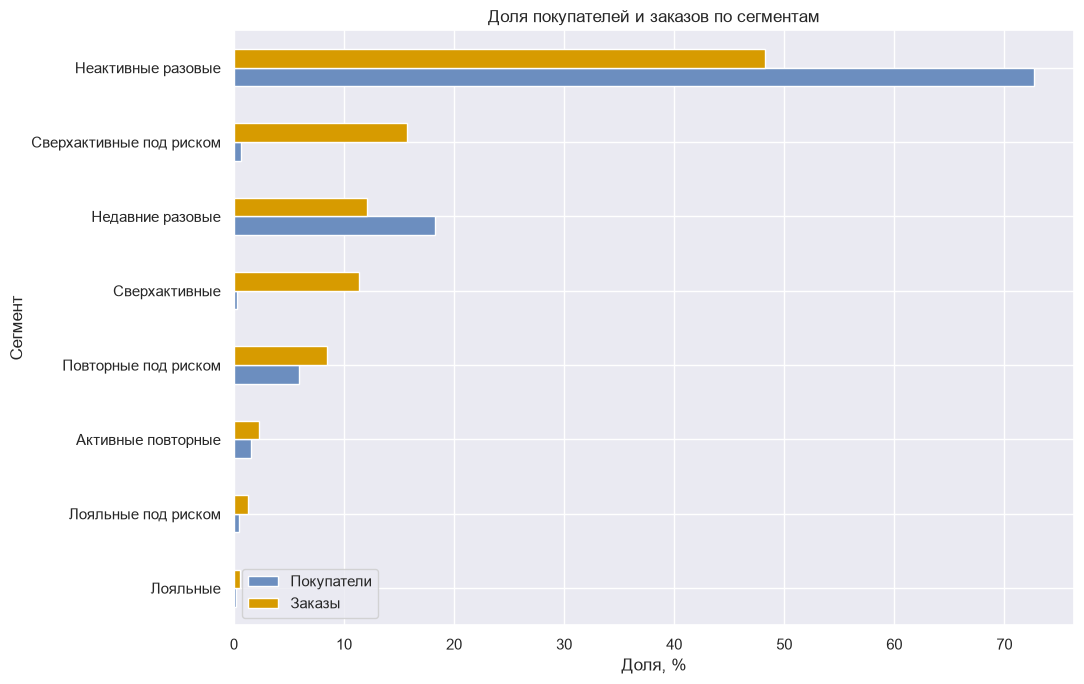

In [86]:
segment_plot = (
    segment_summary[
        ["buyers_share", "orders_share"]
    ]
    .sort_values("orders_share")
)

segment_plot.plot(
    kind="barh",
    figsize=(11, 7),
    color=["#6C8EBF", "#D79B00"]
)

plt.title("Доля покупателей и заказов по сегментам")
plt.xlabel("Доля, %")
plt.ylabel("Сегмент")
plt.legend(["Покупатели", "Заказы"])
plt.tight_layout()
plt.show()

### Выводы по сегментации покупателей

Покупательская база характеризуется низкой повторяемостью заказов: 90,93% покупателей совершили только один заказ. Неактивные разовые покупатели составляют 72,69% аудитории и создают 48,21% всех заказов преимущественно благодаря большой численности сегмента

Сверхактивные покупатели составляют только 0,96% покупателей, но формируют 27,18% заказов. Их следует анализировать отдельно, поскольку в сегменте могут присутствовать корпоративные, тестовые или автоматизированные аккаунты

Приоритетной аудиторией для пилотной кампании возврата являются повторные и лояльные покупатели под риском. В нее входят 747 покупателей, ранее совершивших 1 716 заказов. Эти клиенты уже подтвердили склонность к повторным покупкам, поэтому ожидаемая эффективность контакта с ними может быть выше, чем с неактивными разовыми покупателями

Недавним разовым покупателям можно предложить стимул для второго заказа. Неактивных разовых покупателей целесообразно использовать в более дешевых массовых каналах коммуникации. Сверхактивных покупателей следует предварительно проверить и обслуживать отдельно

Сегментация носит описательный характер. Статус «под риском» означает отсутствие заказа более 30 дней до окончания наблюдаемого периода, но не доказывает окончательный уход покупателя, поскольку будущие заказы в данных отсутствуют

In [87]:
buyers.reset_index().to_csv(
    "../data/processed/user_segments.csv",
    index=False
)

segment_summary.reset_index().to_csv(
    "../data/processed/user_segment_summary.csv",
    index=False
)

# Когортный анализ удержания

Покупатели объединяются в когорты по месяцу первого наблюдаемого заказа. Удержание показывает долю покупателей когорты, которые снова совершили заказ через определенное количество календарных месяцев

Показатель когортного удержания отличается от общей доли повторных покупателей: повторные покупатели рассчитываются за весь период, а когортный анализ учитывает время, прошедшее с месяца первой наблюдаемой покупки

In [88]:
cohort_orders = orders[
    ["transactionid", "visitorid", "order_time"]
].copy()

# Убираем часовой пояс перед преобразованием в месячный период
cohort_orders["order_month"] = (
    cohort_orders["order_time"]
    .dt.tz_localize(None)
    .dt.to_period("M")
    .dt.to_timestamp()
)

cohort_orders["cohort_month"] = (
    cohort_orders
    .groupby("visitorid")["order_month"]
    .transform("min")
)

cohort_orders["cohort_index"] = (
    (
        cohort_orders["order_month"].dt.year
        - cohort_orders["cohort_month"].dt.year
    ) * 12
    + (
        cohort_orders["order_month"].dt.month
        - cohort_orders["cohort_month"].dt.month
    )
)

display(cohort_orders.head())

,transactionid,visitorid,order_time,order_month,cohort_month,cohort_index
0,0,90352,2015-06-15 21:36:37.081000+00:00,2015-06-01,2015-06-01,0
1,1,1150086,2015-07-14 18:30:08.851000+00:00,2015-07-01,2015-06-01,1
2,2,556967,2015-06-03 18:02:29.857000+00:00,2015-06-01,2015-06-01,0
3,3,424452,2015-06-22 00:12:41.626000+00:00,2015-06-01,2015-06-01,0
4,4,531661,2015-06-07 22:40:24.966000+00:00,2015-06-01,2015-05-01,1


In [89]:
cohort_counts = (
    cohort_orders
    .groupby(["cohort_month", "cohort_index"])["visitorid"]
    .nunique()
    .unstack()
    .sort_index()
)

display(cohort_counts)

cohort_index,0,1,2,3,4
cohort_month,,,,,
2015-05-01,2546.0,76.0,46.0,25.0,14.0
2015-06-01,2652.0,45.0,19.0,11.0,NaN
2015-07-01,2880.0,32.0,10.0,NaN,NaN
2015-08-01,2422.0,36.0,NaN,NaN,NaN
2015-09-01,1219.0,NaN,NaN,NaN,NaN


In [90]:
last_order_month = cohort_orders["order_month"].max()

all_periods = range(
    int(cohort_orders["cohort_index"].max()) + 1
)

cohort_counts = cohort_counts.reindex(columns=all_periods)

for cohort_month in cohort_counts.index:
    available_months = (
        (last_order_month.year - cohort_month.year) * 12
        + (last_order_month.month - cohort_month.month)
    )

    available_columns = [
        column
        for column in cohort_counts.columns
        if column <= available_months
    ]

    cohort_counts.loc[
        cohort_month,
        available_columns
    ] = cohort_counts.loc[
        cohort_month,
        available_columns
    ].fillna(0)

cohort_counts.columns = [
    f"M+{column}" for column in cohort_counts.columns
]

display(cohort_counts)

,M+0,M+1,M+2,M+3,M+4
cohort_month,,,,,
2015-05-01,2546.0,76.0,46.0,25.0,14.0
2015-06-01,2652.0,45.0,19.0,11.0,NaN
2015-07-01,2880.0,32.0,10.0,NaN,NaN
2015-08-01,2422.0,36.0,NaN,NaN,NaN
2015-09-01,1219.0,NaN,NaN,NaN,NaN


In [91]:
cohort_sizes = cohort_counts["M+0"]

retention_matrix = (
    cohort_counts
    .div(cohort_sizes, axis=0)
    .mul(100)
    .round(2)
)

display(retention_matrix)

,M+0,M+1,M+2,M+3,M+4
cohort_month,,,,,
2015-05-01,100.0,2.99,1.81,0.98,0.55
2015-06-01,100.0,1.70,0.72,0.41,NaN
2015-07-01,100.0,1.11,0.35,NaN,NaN
2015-08-01,100.0,1.49,NaN,NaN,NaN
2015-09-01,100.0,NaN,NaN,NaN,NaN


In [92]:
print(
    "Покупателей в когортах:",
    int(cohort_sizes.sum())
)

print(
    "Всего покупателей:",
    buyers.index.nunique()
)

Покупателей в когортах: 11719
Всего покупателей: 11719


In [93]:
retention_display = retention_matrix.copy()

retention_display.index = (
    retention_display.index
    .strftime("%Y-%m")
)

display(retention_display)

,M+0,M+1,M+2,M+3,M+4
cohort_month,,,,,
2015-05,100.0,2.99,1.81,0.98,0.55
2015-06,100.0,1.70,0.72,0.41,NaN
2015-07,100.0,1.11,0.35,NaN,NaN
2015-08,100.0,1.49,NaN,NaN,NaN
2015-09,100.0,NaN,NaN,NaN,NaN


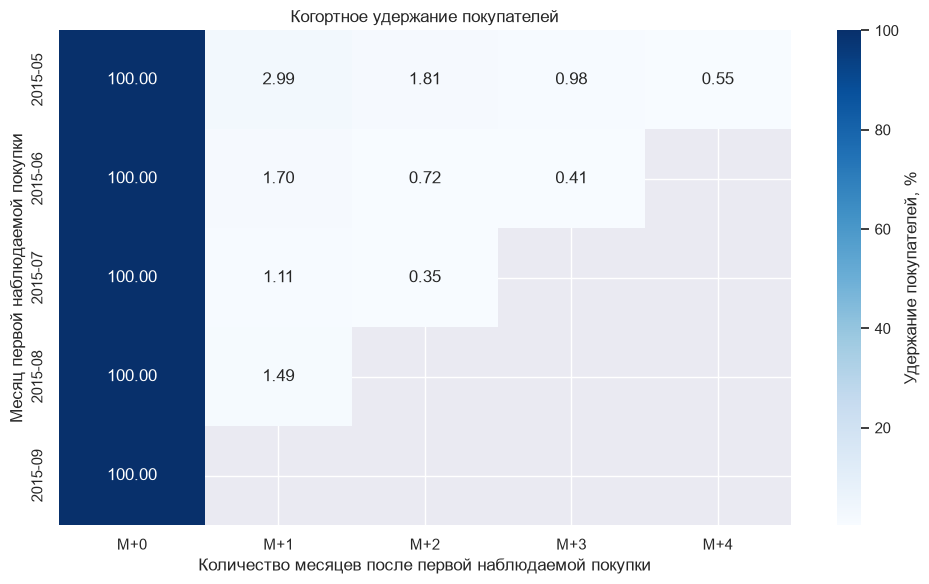

In [94]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    retention_display,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    mask=retention_display.isna(),
    cbar_kws={"label": "Удержание покупателей, %"}
)

plt.title("Когортное удержание покупателей")
plt.xlabel("Количество месяцев после первой наблюдаемой покупки")
plt.ylabel("Месяц первой наблюдаемой покупки")
plt.tight_layout()
plt.show()

In [95]:
retention_complete = retention_matrix.copy()

last_complete_month = pd.Timestamp("2015-08-01")

for cohort_month in retention_complete.index:
    for column in retention_complete.columns:
        period_number = int(column.replace("M+", ""))

        # M+0 оставляем как размер исходной когорты
        if period_number == 0:
            continue

        target_month = (
            cohort_month
            + pd.DateOffset(months=period_number)
        )

        if target_month > last_complete_month:
            retention_complete.loc[cohort_month, column] = np.nan

retention_complete_display = retention_complete.copy()
retention_complete_display.index = (
    retention_complete_display.index.strftime("%Y-%m")
)

display(retention_complete_display)

,M+0,M+1,M+2,M+3,M+4
cohort_month,,,,,
2015-05,100.0,2.99,1.81,0.98,NaN
2015-06,100.0,1.70,0.72,NaN,NaN
2015-07,100.0,1.11,NaN,NaN,NaN
2015-08,100.0,NaN,NaN,NaN,NaN
2015-09,100.0,NaN,NaN,NaN,NaN


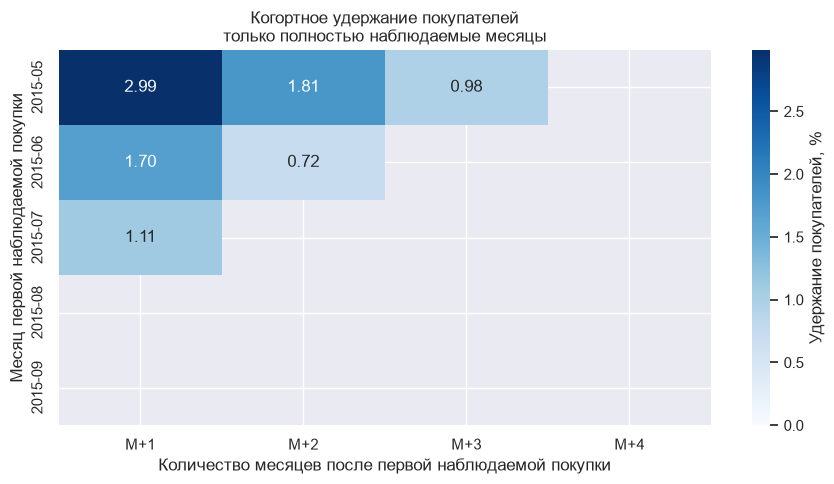

In [96]:
retention_heatmap = retention_complete_display.drop(
    columns="M+0"
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    retention_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    mask=retention_heatmap.isna(),
    vmin=0,
    vmax=np.nanmax(retention_heatmap.to_numpy()),
    cbar_kws={"label": "Удержание покупателей, %"}
)

plt.title(
    "Когортное удержание покупателей\n"
    "только полностью наблюдаемые месяцы"
)
plt.xlabel("Количество месяцев после первой наблюдаемой покупки")
plt.ylabel("Месяц первой наблюдаемой покупки")
plt.tight_layout()
plt.show()

**Вывод**

Среди полностью наблюдаемых когорт максимальное удержание M+1 зафиксировано в мае — 2,99%. В июне показатель составил 1,70%, а в июле — 1,11%. Наблюдается снижение, однако короткий период анализа, небольшое количество когорт и левое цензурирование не позволяют считать его устойчивым долгосрочным трендом.

## Возврат к повторной покупке за фиксированный период

Календарное когортное удержание зависит от положения заказа относительно границы месяца. Поэтому дополнительно рассчитывается доля покупателей, совершивших второй заказ в течение 7, 30, 60 и 90 дней после первого наблюдаемого заказа

Для каждого временного окна используются только покупатели, для которых после первого заказа доступен полный период наблюдения. Показатели являются кумулятивными: покупатель, вернувшийся в течение 30 дней, также учитывается в окнах 60 и 90 дней

In [97]:
order_sequence = (
    orders
    .sort_values(
        ["visitorid", "order_time", "transactionid"]
    )
    .copy()
)

order_sequence["order_number"] = (
    order_sequence
    .groupby("visitorid")
    .cumcount()
    .add(1)
)

first_orders = (
    order_sequence
    .loc[
        order_sequence["order_number"] == 1,
        ["visitorid", "order_time"]
    ]
    .set_index("visitorid")
    .rename(columns={"order_time": "first_order"})
)

second_orders = (
    order_sequence
    .loc[
        order_sequence["order_number"] == 2,
        ["visitorid", "order_time"]
    ]
    .set_index("visitorid")
    .rename(columns={"order_time": "second_order"})
)

repeat_timing = first_orders.join(
    second_orders,
    how="left"
)

repeat_timing["days_to_second_order"] = (
    repeat_timing["second_order"]
    - repeat_timing["first_order"]
).dt.total_seconds().div(86400)

display(repeat_timing.head())

,first_order,second_order,days_to_second_order
visitorid,,,
172,2015-08-15 01:29:01.230000+00:00,NaT,NaN
186,2015-08-12 16:34:57.040000+00:00,NaT,NaN
264,2015-09-07 17:34:45.614000+00:00,NaT,NaN
419,2015-07-29 05:03:12.695000+00:00,NaT,NaN
539,2015-06-16 05:39:38.673000+00:00,NaT,NaN


In [98]:
print("Покупателей:", len(repeat_timing))

print(
    "Покупателей со вторым заказом:",
    repeat_timing["second_order"].notna().sum()
)

print(
    "Отрицательных интервалов:",
    repeat_timing["days_to_second_order"].lt(0).sum()
)

Покупателей: 11719
Покупателей со вторым заказом: 1063
Отрицательных интервалов: 0


In [99]:
display(
    repeat_timing["days_to_second_order"]
    .dropna()
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .round(2)
)

count    1063.00
mean        6.54
std        15.94
min         0.00
25%         0.01
50%         0.07
75%         3.78
90%        21.79
95%        42.08
99%        83.09
max       112.48
Name: days_to_second_order, dtype: float64

In [100]:
print(
    "Второй заказ в ту же минуту:",
    (
        repeat_timing["days_to_second_order"]
        .le(1 / 1440)
    ).sum()
)

print(
    "Второй заказ в течение часа:",
    (
        repeat_timing["days_to_second_order"]
        .le(1 / 24)
    ).sum()
)

Второй заказ в ту же минуту: 4
Второй заказ в течение часа: 494


In [101]:
analysis_end = orders["order_time"].max()

windows = [7, 30, 60, 90]
repeat_window_rows = []

for window_days in windows:
    eligibility_cutoff = (
        analysis_end
        - pd.Timedelta(days=window_days)
    )

    eligible_mask = (
        repeat_timing["first_order"]
        <= eligibility_cutoff
    )

    returned_mask = (
        eligible_mask
        & repeat_timing["second_order"].notna()
        & (
            repeat_timing["second_order"]
            <= repeat_timing["first_order"]
            + pd.Timedelta(days=window_days)
        )
    )

    eligible_buyers = eligible_mask.sum()
    returned_buyers = returned_mask.sum()

    repeat_window_rows.append({
        "window_days": window_days,
        "eligibility_cutoff": eligibility_cutoff,
        "eligible_buyers": eligible_buyers,
        "returned_buyers": returned_buyers,
        "repeat_rate": (
            returned_buyers
            / eligible_buyers
            * 100
        )
    })

repeat_window_summary = (
    pd.DataFrame(repeat_window_rows)
    .set_index("window_days")
)

repeat_window_summary["repeat_rate"] = (
    repeat_window_summary["repeat_rate"].round(2)
)

display(repeat_window_summary)

,eligibility_cutoff,eligible_buyers,returned_buyers,repeat_rate
window_days,,,,
7,2015-09-11 02:43:12.017000+00:00,11278,829,7.35
30,2015-08-19 02:43:12.017000+00:00,9445,836,8.85
60,2015-07-20 02:43:12.017000+00:00,6864,676,9.85
90,2015-06-20 02:43:12.017000+00:00,4256,486,11.42


In [102]:
print(
    "Количество подходящих покупателей уменьшается:",
    repeat_window_summary[
        "eligible_buyers"
    ].is_monotonic_decreasing
)

Количество подходящих покупателей уменьшается: True


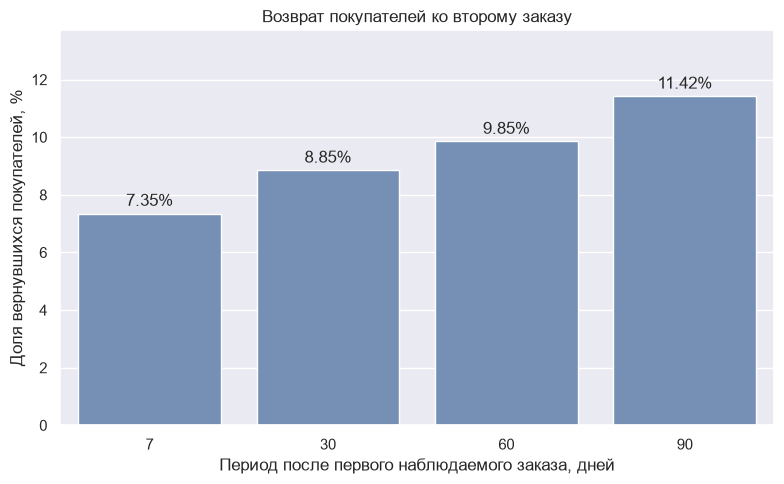

In [103]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=repeat_window_summary.reset_index(),
    x="window_days",
    y="repeat_rate",
    color="#6C8EBF"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.title("Возврат покупателей ко второму заказу")
plt.xlabel("Период после первого наблюдаемого заказа, дней")
plt.ylabel("Доля вернувшихся покупателей, %")
plt.ylim(
    0,
    repeat_window_summary["repeat_rate"].max() * 1.2
)
plt.tight_layout()
plt.show()

In [104]:
order_sequence = (
    orders[
        ["transactionid", "visitorid", "order_time"]
    ]
    .sort_values(
        ["visitorid", "order_time", "transactionid"]
    )
    .copy()
)

order_sequence["order_number"] = (
    order_sequence
    .groupby("visitorid")
    .cumcount()
    .add(1)
)

first_order_info = (
    order_sequence
    .loc[
        order_sequence["order_number"] == 1,
        ["visitorid", "transactionid", "order_time"]
    ]
    .set_index("visitorid")
    .rename(columns={
        "transactionid": "first_transactionid",
        "order_time": "first_order"
    })
)

second_order_info = (
    order_sequence
    .loc[
        order_sequence["order_number"] == 2,
        ["visitorid", "transactionid", "order_time"]
    ]
    .set_index("visitorid")
    .rename(columns={
        "transactionid": "second_transactionid",
        "order_time": "second_order"
    })
)

repeat_pairs = first_order_info.join(
    second_order_info,
    how="left"
)

repeat_pairs["gap_hours"] = (
    repeat_pairs["second_order"]
    - repeat_pairs["first_order"]
).dt.total_seconds().div(3600)

display(repeat_pairs.head())

,first_transactionid,first_order,second_transactionid,second_order,gap_hours
visitorid,,,,,
172,9725,2015-08-15 01:29:01.230000+00:00,<NA>,NaT,NaN
186,8726,2015-08-12 16:34:57.040000+00:00,<NA>,NaT,NaN
264,8445,2015-09-07 17:34:45.614000+00:00,<NA>,NaT,NaN
419,16455,2015-07-29 05:03:12.695000+00:00,<NA>,NaT,NaN
539,14778,2015-06-16 05:39:38.673000+00:00,<NA>,NaT,NaN


In [105]:
basket_sets = (
    order_items
    .groupby("transactionid")["itemid"]
    .agg(frozenset)
)

repeat_pairs["first_basket"] = (
    repeat_pairs["first_transactionid"]
    .map(basket_sets)
)

repeat_pairs["second_basket"] = (
    repeat_pairs["second_transactionid"]
    .map(basket_sets)
)

repeat_pairs["identical_baskets"] = repeat_pairs.apply(
    lambda row: (
        row["first_basket"] == row["second_basket"]
        if pd.notna(row["second_order"])
        else False
    ),
    axis=1
)

repeat_pairs["has_item_overlap"] = repeat_pairs.apply(
    lambda row: (
        len(row["first_basket"] & row["second_basket"]) > 0
        if pd.notna(row["second_order"])
        else False
    ),
    axis=1
)

In [106]:
quick_repeat_pairs = repeat_pairs.loc[
    repeat_pairs["gap_hours"].le(1)
].copy()

quick_diagnostics = pd.Series({
    "quick_pairs_count": len(quick_repeat_pairs),

    "identical_baskets_count":
        quick_repeat_pairs["identical_baskets"].sum(),

    "identical_baskets_share":
        quick_repeat_pairs["identical_baskets"].mean() * 100,

    "overlapping_baskets_count":
        quick_repeat_pairs["has_item_overlap"].sum(),

    "overlapping_baskets_share":
        quick_repeat_pairs["has_item_overlap"].mean() * 100
})

display(quick_diagnostics.round(2))

quick_pairs_count            494.00
identical_baskets_count      286.00
identical_baskets_share       57.89
overlapping_baskets_count    319.00
overlapping_baskets_share     64.57
dtype: float64

In [107]:
order_sequence = order_sequence.merge(
    first_order_info[["first_order"]],
    left_on="visitorid",
    right_index=True,
    how="left"
)

order_sequence["hours_from_first"] = (
    order_sequence["order_time"]
    - order_sequence["first_order"]
).dt.total_seconds().div(3600)

In [108]:
def get_first_return_after(cooldown_hours):
    return (
        order_sequence
        .loc[
            (order_sequence["order_number"] > 1)
            & (
                order_sequence["hours_from_first"]
                >= cooldown_hours
            )
        ]
        .groupby("visitorid")["order_time"]
        .min()
    )

In [109]:
analysis_end = orders["order_time"].max()

common_eligible_mask = (
    first_order_info["first_order"]
    <= analysis_end - pd.Timedelta(days=90)
)

common_buyers = first_order_info.index[
    common_eligible_mask
]

print(
    "Покупателей с полными 90 днями наблюдения:",
    len(common_buyers)
)

Покупателей с полными 90 днями наблюдения: 4256


In [110]:
windows = [7, 30, 60, 90]
cooldowns = [0, 1, 24]

sensitivity_rows = []

for cooldown_hours in cooldowns:
    first_return = get_first_return_after(
        cooldown_hours
    ).reindex(common_buyers)

    first_order = first_order_info.loc[
        common_buyers,
        "first_order"
    ]

    for window_days in windows:
        returned_mask = (
            first_return.notna()
            & (
                first_return
                <= first_order
                + pd.Timedelta(days=window_days)
            )
        )

        sensitivity_rows.append({
            "cooldown_hours": cooldown_hours,
            "window_days": window_days,
            "eligible_buyers": len(common_buyers),
            "returned_buyers": returned_mask.sum(),
            "repeat_rate": (
                returned_mask.mean() * 100
            )
        })

repeat_sensitivity = pd.DataFrame(
    sensitivity_rows
)

repeat_sensitivity["repeat_rate"] = (
    repeat_sensitivity["repeat_rate"].round(2)
)

display(repeat_sensitivity)

,cooldown_hours,window_days,eligible_buyers,returned_buyers,repeat_rate
0,0,7,4256,371,8.72
1,0,30,4256,440,10.34
2,0,60,4256,473,11.11
3,0,90,4256,486,11.42
4,1,7,4256,200,4.70
5,1,30,4256,276,6.48
6,1,60,4256,311,7.31
7,1,90,4256,326,7.66
8,24,7,4256,109,2.56
9,24,30,4256,191,4.49


In [111]:
repeat_sensitivity_matrix = (
    repeat_sensitivity
    .pivot(
        index="cooldown_hours",
        columns="window_days",
        values="repeat_rate"
    )
)

repeat_sensitivity_matrix.index = [
    "Без ограничения",
    "После 1 часа",
    "После 24 часов"
]

repeat_sensitivity_matrix.columns = [
    "7 дней",
    "30 дней",
    "60 дней",
    "90 дней"
]

display(repeat_sensitivity_matrix)

,7 дней,30 дней,60 дней,90 дней
Без ограничения,8.72,10.34,11.11,11.42
После 1 часа,4.70,6.48,7.31,7.66
После 24 часов,2.56,4.49,5.31,5.69


In [112]:
adjusted_first_return = get_first_return_after(
    cooldown_hours=1
)

adjusted_window_rows = []

for window_days in [7, 30, 60, 90]:
    eligibility_cutoff = (
        analysis_end
        - pd.Timedelta(days=window_days)
    )

    eligible_buyers = first_order_info.index[
        first_order_info["first_order"]
        <= eligibility_cutoff
    ]

    eligible_first_orders = first_order_info.loc[
        eligible_buyers,
        "first_order"
    ]

    eligible_returns = adjusted_first_return.reindex(
        eligible_buyers
    )

    returned_mask = (
        eligible_returns.notna()
        & (
            eligible_returns
            <= eligible_first_orders
            + pd.Timedelta(days=window_days)
        )
    )

    adjusted_window_rows.append({
        "window_days": window_days,
        "eligible_buyers": len(eligible_buyers),
        "returned_buyers": returned_mask.sum(),
        "adjusted_repeat_rate": (
            returned_mask.mean() * 100
        )
    })

adjusted_repeat_summary = (
    pd.DataFrame(adjusted_window_rows)
    .set_index("window_days")
)

adjusted_repeat_summary[
    "adjusted_repeat_rate"
] = adjusted_repeat_summary[
    "adjusted_repeat_rate"
].round(2)

display(adjusted_repeat_summary)

,eligible_buyers,returned_buyers,adjusted_repeat_rate
window_days,,,
7,11278,430,3.81
30,9445,505,5.35
60,6864,431,6.28
90,4256,326,7.66


In [113]:
repeat_comparison = (
    repeat_window_summary[
        [
            "eligible_buyers",
            "returned_buyers",
            "repeat_rate"
        ]
    ]
    .rename(columns={
        "returned_buyers": "raw_returned_buyers",
        "repeat_rate": "raw_repeat_rate"
    })
    .join(
        adjusted_repeat_summary[
            [
                "returned_buyers",
                "adjusted_repeat_rate"
            ]
        ].rename(columns={
            "returned_buyers":
                "adjusted_returned_buyers"
        })
    )
)

repeat_comparison["difference_pp"] = (
    repeat_comparison["raw_repeat_rate"]
    - repeat_comparison["adjusted_repeat_rate"]
).round(2)

display(repeat_comparison)

,eligible_buyers,raw_returned_buyers,raw_repeat_rate,adjusted_returned_buyers,adjusted_repeat_rate,difference_pp
window_days,,,,,,
7,11278,829,7.35,430,3.81,3.54
30,9445,836,8.85,505,5.35,3.50
60,6864,676,9.85,431,6.28,3.57
90,4256,486,11.42,326,7.66,3.76


In [114]:
repeat_comparison.reset_index().to_csv(
    "../data/processed/repeat_purchase_metrics.csv",
    index=False
)

repeat_sensitivity.to_csv(
    "../data/processed/repeat_purchase_sensitivity.csv",
    index=False
)

retention_complete.reset_index().to_csv(
    "../data/processed/cohort_retention.csv",
    index=False
)

30-дневный возврат ко второму заказу после часового интервала - 5,35% среди 9 445 покупателей с полным периодом наблюдения

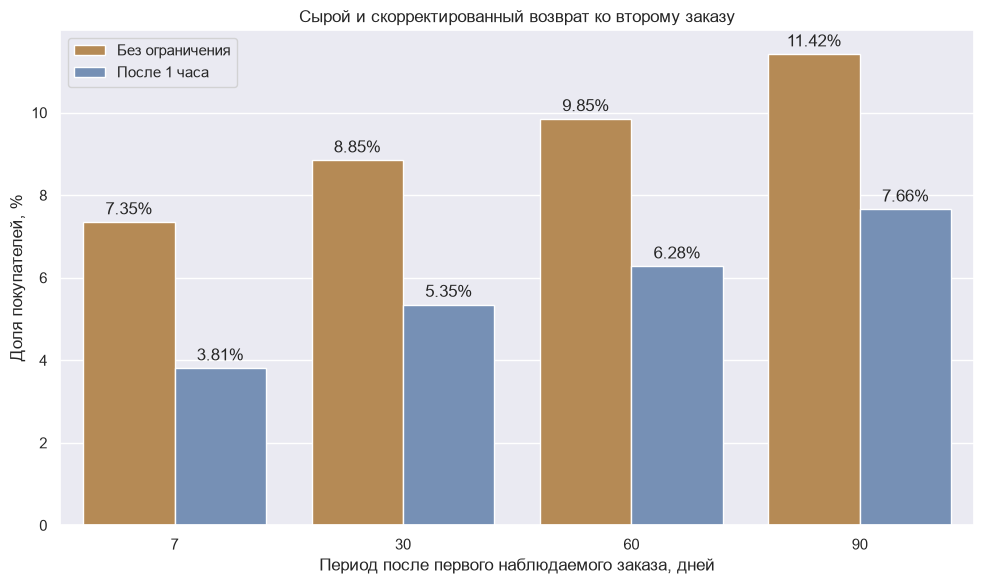

In [115]:
repeat_plot_data = (
    repeat_comparison
    .reset_index()
    .melt(
        id_vars="window_days",
        value_vars=[
            "raw_repeat_rate",
            "adjusted_repeat_rate"
        ],
        var_name="metric",
        value_name="repeat_rate"
    )
)

repeat_plot_data["metric"] = (
    repeat_plot_data["metric"].map({
        "raw_repeat_rate": "Без ограничения",
        "adjusted_repeat_rate": "После 1 часа"
    })
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=repeat_plot_data,
    x="window_days",
    y="repeat_rate",
    hue="metric",
    palette=["#C58B45", "#6C8EBF"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.title("Сырой и скорректированный возврат ко второму заказу")
plt.xlabel("Период после первого наблюдаемого заказа, дней")
plt.ylabel("Доля покупателей, %")
plt.legend(title="")
plt.tight_layout()
plt.show()

## Итоговые выводы по покупателям

В данных представлены 1 407 580 пользователей, из которых 11 719 совершили хотя бы одну покупку. Всего зарегистрировано 17 672 уникальных заказа

### Повторные покупки

Большинство покупателей совершили только один заказ:

- 10 656 покупателей, или 90,93%, совершили один заказ
- 1 063 покупателя, или 9,07%, совершили два заказа и более
- медианное количество заказов равно 1
- среднее количество заказов равно 1,51 и повышается под влиянием небольшой группы сверхактивных покупателей

Распределение количества заказов имеет выраженный правый хвост. Максимальное количество заказов одного покупателя равно 502. Топ-1% покупателей формирует 27,38% заказов, а самый активный покупатель — 2,84% всех заказов. Такие аккаунты не следует автоматически удалять, однако их необходимо анализировать отдельно

### Сегментация

Неактивные разовые покупатели составляют 72,69% покупателей и формируют 48,21% заказов. Их большой вклад объясняется численностью сегмента, а не высокой частотой покупок

Сверхактивные покупатели составляют около 0,96% аудитории, но формируют 27,18% заказов. В этом сегменте могут присутствовать корпоративные, тестовые или автоматизированные аккаунты

Для пилотной кампании возврата целесообразно использовать повторных и лояльных покупателей под риском. Эти клиенты уже подтвердили склонность к повторным заказам. Недавним разовым покупателям можно предложить стимул для второй покупки, а неактивных разовых покупателей использовать в менее затратных массовых каналах

### Когортное удержание

Среди полностью наблюдаемых когорт максимальное удержание M+1 зафиксировано в мае — 2,99%. Для июньской когорты оно составило 1,70%, для июльской — 1,11%

Наблюдается снижение межмесячного удержания, однако короткий период анализа, малое количество полных когорт и левое цензурирование не позволяют считать его устойчивым долгосрочным трендом. Первая наблюдаемая покупка может не являться первой покупкой клиента за все время его взаимодействия с магазином

### Возврат за фиксированный период

Проверка быстрых последовательных транзакций показала, что 494 вторых заказа произошли в течение часа. В 57,89% случаев корзины двух заказов полностью совпадали, а в 64,57% содержали хотя бы один общий товар. Поэтому сырые показатели повторных заказов могут быть завышены

После применения часового интервала между первой покупкой и учитываемым повторным заказом получены следующие показатели:

- за 7 дней вернулись 3,81% подходящих покупателей
- за 30 дней — 5,35%
- за 60 дней — 6,28%
- за 90 дней — 7,66%

Сырые показатели выше скорректированных на 3,50–3,76 процентного пункта. Основным показателем рекомендуется использовать 30-дневный возврат после часового интервала — 5,35%. Часовой порог является аналитическим допущением, поэтому результаты без ограничения и с 24-часовым интервалом следует сохранять как анализ чувствительности

### Ограничения

В датасете отсутствуют стоимость заказов, выручка, маржа и признаки покупателей. Поэтому невозможно оценить денежную ценность сегментов и построить полноценный RFM-анализ

Период наблюдения ограничен маем–сентябрем 2015 года. Будущие покупки неизвестны, а первая наблюдаемая покупка не обязательно является первой покупкой клиента за все время

Разные transaction ID считаются отдельными заказами согласно структуре исходных данных. Большое количество быстрых последовательных транзакций создает неопределенность, которую невозможно полностью устранить без бизнес-описания системы заказов

In [116]:
assert len(buyers) == 11719
assert buyers["orders_count"].sum() == 17672
assert buyers["customer_segment"].eq(
    "Не определён"
).sum() == 0

assert repeat_comparison.loc[
    30,
    "adjusted_repeat_rate"
] == 5.35

print("Все итоговые проверки пройдены")

Все итоговые проверки пройдены
